In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, matplotlib.gridspec as gridspec
import seaborn as sns

# ── 1. LOAD & INSPECT DATASET ─────────────────────────────────────────
df = sns.load_dataset('tips') # Menggunakan dataset 'tips' (restoran)
print(df.shape, df.dtypes)
print(df.describe().round(2))

(244, 7) total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object
       total_bill     tip    size
count      244.00  244.00  244.00
mean        19.79    3.00    2.57
std          8.90    1.38    0.95
min          3.07    1.00    1.00
25%         13.35    2.00    2.00
50%         17.80    2.90    2.00
75%         24.13    3.56    3.00
max         50.81   10.00    6.00


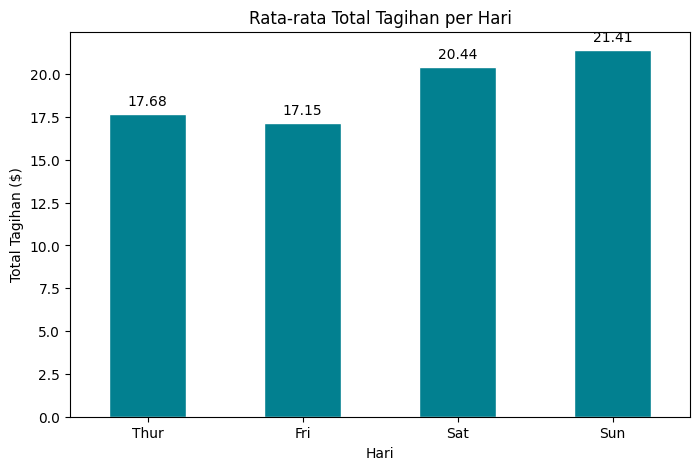

In [2]:
# Pastikan observasi di-group berdasarkan hari
avg_by_day = df.groupby('day', observed=False)['total_bill'].mean()

plt.figure(figsize=(8, 5))
avg_by_day.plot(
    kind='bar',
    color='#028090',
    edgecolor='white'
)

plt.title('Rata-rata Total Tagihan per Hari')
plt.xlabel('Hari')
plt.ylabel('Total Tagihan ($)')
plt.xticks(rotation=0)

# Label nilai
for i, v in enumerate(avg_by_day):
    plt.text(i, v + 0.5, f'{v:.2f}', ha='center') # Menyesuaikan offset label

plt.show()

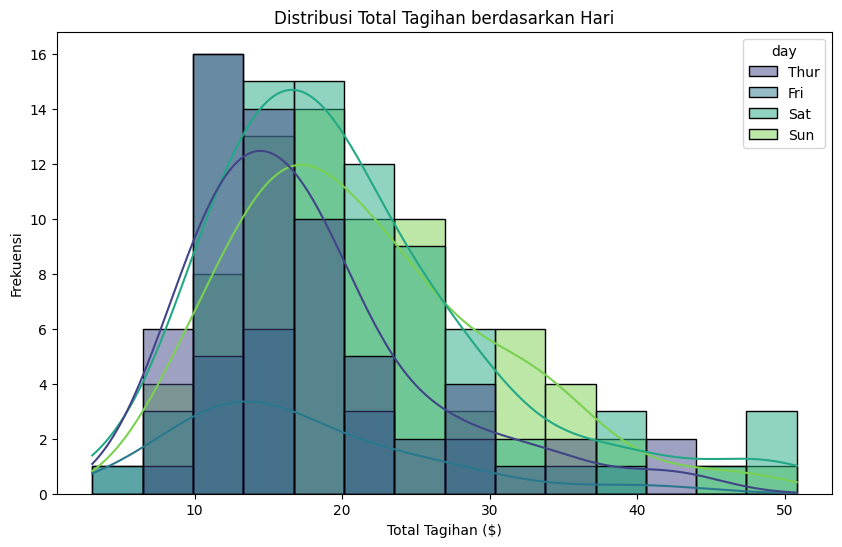

In [3]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='total_bill',
    hue='day',
    kde=True,
    palette='viridis'
)

plt.title('Distribusi Total Tagihan berdasarkan Hari')
plt.xlabel('Total Tagihan ($)')
plt.ylabel('Frekuensi')

# Mengatur letak legend agar rapi
plt.show()

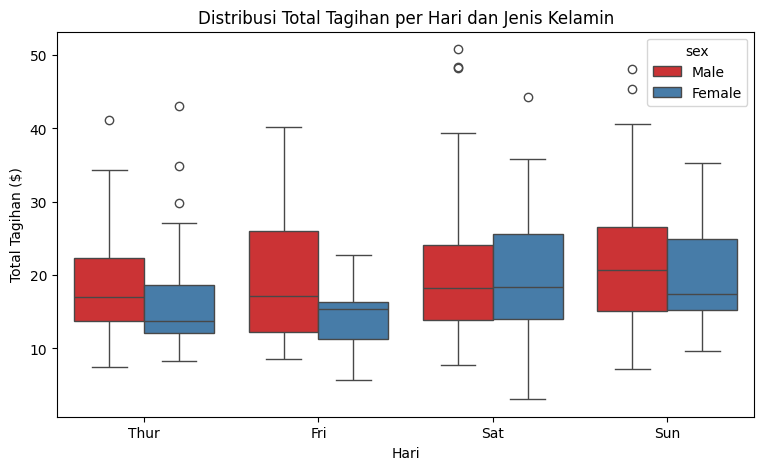

In [4]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x='day',
    y='total_bill',
    hue='sex',
    palette='Set1'
)

plt.title('Distribusi Total Tagihan per Hari dan Jenis Kelamin')
plt.xlabel('Hari')
plt.ylabel('Total Tagihan ($)')
plt.show()

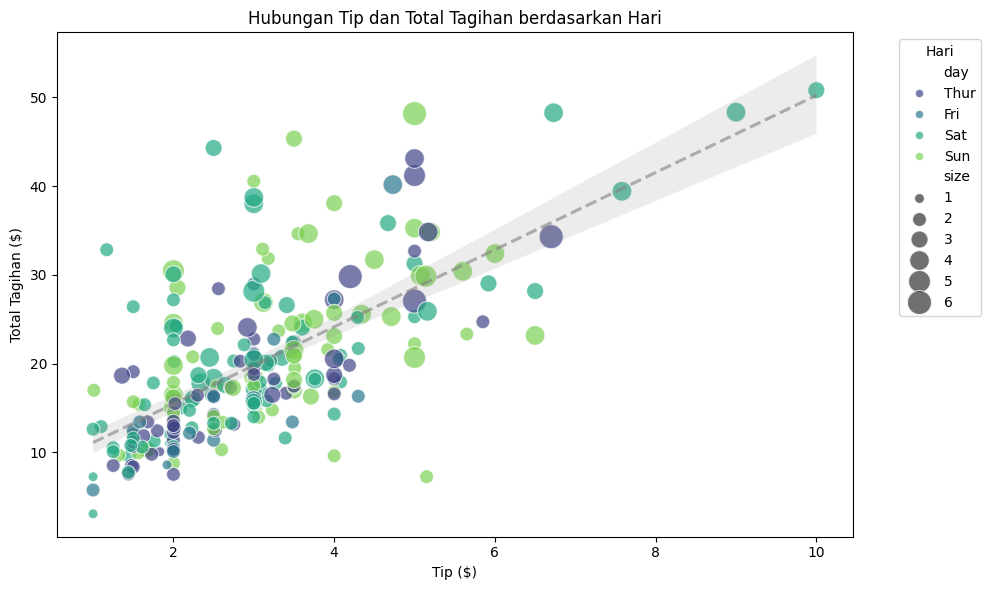

In [5]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='tip',
    y='total_bill',
    hue='day',
    size='size',
    sizes=(50, 300),
    palette='viridis',
    alpha=0.7
)

sns.regplot(
    data=df,
    x='tip',
    y='total_bill',
    scatter=False,
    color='gray',
    line_kws={'linestyle': '--', 'alpha': 0.6}
)

plt.title('Hubungan Tip dan Total Tagihan berdasarkan Hari')
plt.xlabel('Tip ($)')
plt.ylabel('Total Tagihan ($)')
plt.legend(title='Hari', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1918/1754672058.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


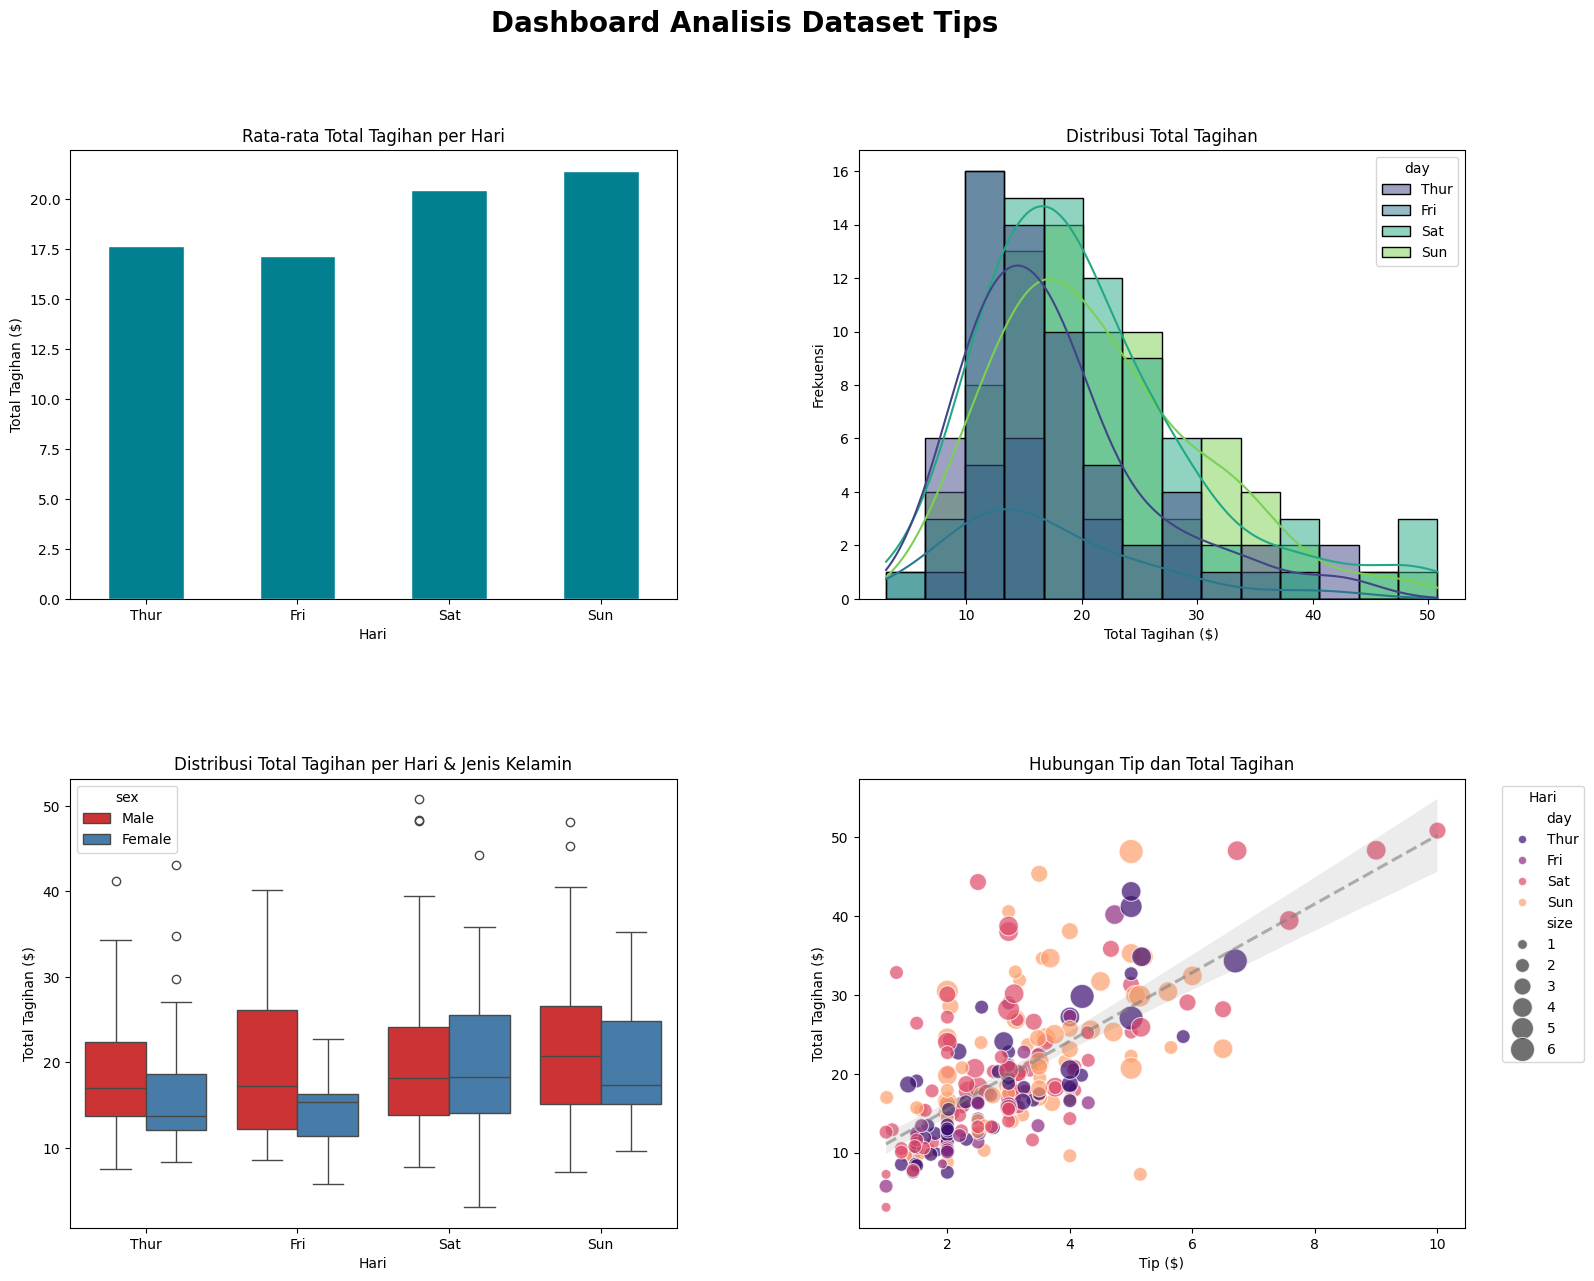

Dashboard tersimpan sebagai dashboard_tips.png


In [6]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle('Dashboard Analisis Dataset Tips', fontsize=20, fontweight='bold')

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# 1. Bar Chart
avg_by_day = df.groupby('day', observed=False)['total_bill'].mean()
avg_by_day.plot(kind='bar', ax=ax1, color='#028090', edgecolor='white')
ax1.set_title('Rata-rata Total Tagihan per Hari')
ax1.set_xlabel('Hari')
ax1.set_ylabel('Total Tagihan ($)')
ax1.tick_params(axis='x', rotation=0)

# 2. Histogram
sns.histplot(data=df, x='total_bill', hue='day', kde=True, palette='viridis', ax=ax2)
ax2.set_title('Distribusi Total Tagihan')
ax2.set_xlabel('Total Tagihan ($)')
ax2.set_ylabel('Frekuensi')

# 3. Boxplot
sns.boxplot(data=df, x='day', y='total_bill', hue='sex', palette='Set1', ax=ax3)
ax3.set_title('Distribusi Total Tagihan per Hari & Jenis Kelamin')
ax3.set_xlabel('Hari')
ax3.set_ylabel('Total Tagihan ($)')

# 4. Scatter Plot
sns.scatterplot(
    data=df,
    x='tip',
    y='total_bill',
    hue='day',
    size='size',
    sizes=(50, 300),
    palette='magma',
    alpha=0.7,
    ax=ax4
)
sns.regplot(data=df, x='tip', y='total_bill', scatter=False, color='gray', line_kws={'linestyle': '--', 'alpha': 0.6}, ax=ax4)
ax4.set_title('Hubungan Tip dan Total Tagihan')
ax4.set_xlabel('Tip ($)')
ax4.set_ylabel('Total Tagihan ($)')
ax4.legend(title='Hari', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('dashboard_tips.png', dpi=150, bbox_inches='tight')
plt.show()

print("Dashboard tersimpan sebagai dashboard_tips.png")

1. What? (Apa yang ditampilkan?)
Dashboard ini menampilkan empat analisis visual dari data transaksi restoran (dataset 'tips'). Grafik ini mencakup rata-rata total tagihan per hari, distribusi frekuensi tagihan (yang didominasi kisaran $10–$20), perbandingan rentang pengeluaran antara pria dan wanita per harinya, serta korelasi positif antara total tagihan dan besaran tip.

2. So What? (Apa maknanya?)
Dari grafik tersebut, terlihat jelas bahwa puncak transaksi dan pengeluaran tertinggi terjadi pada akhir pekan (Sabtu dan Minggu). Selain itu, pelanggan pria sering kali mencatat tagihan yang sangat tinggi (outliers), dan terbukti bahwa semakin besar total pesanan meja beserta jumlah rombongannya, semakin besar pula tip yang mereka tinggalkan.

3. Now What? (Apa langkah selanjutnya?)
Berdasarkan pola data tersebut, manajemen restoran dapat mengambil tindakan bisnis seperti: menambah jadwal staf pelayan pada hari Sabtu dan Minggu untuk mengimbangi lonjakan pengunjung, serta membuat promo "Paket Keluarga" untuk menarik rombongan besar karena terbukti menghasilkan tagihan dan tip yang paling maksimal.